# Lab Experiment 4
### Subject: Machine Learning Theory and Practice
### Dataset: Mushroom Classification Dataset

## Objective
Predict whether a mushroom is **edible or poisonous** using a **Decision Tree Classifier**.

Dataset Source:
https://archive.ics.uci.edu/dataset/73/mushroom

# 1. Import Required Libraries
In this step, we import all necessary Python libraries for data analysis, visualization, and machine learning.

In [2]:
# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Loading the Dataset
The dataset is loaded using pandas. We then display the first few rows to understand the structure of the dataset.

In [12]:
# Column names because the dataset doesn't include headers
columns = [
'class','cap-shape','cap-surface','cap-color','bruises','odor',
'gill-attachment','gill-spacing','gill-size','gill-color',
'stalk-shape','stalk-root','stalk-surface-above-ring',
'stalk-surface-below-ring','stalk-color-above-ring',
'stalk-color-below-ring','veil-type','veil-color',
'ring-number','ring-type','spore-print-color',
'population','habitat'
]

# Load dataset
df = pd.read_csv("mushroom.csv", names=columns)

# Display first rows
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# 3. Exploratory Data Analysis (EDA)
We explore the dataset to understand its structure and information.

In [13]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (8124, 23)


In [14]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [15]:
# Summary statistics
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


# 4. Data Visualization
Visualizing the distribution of edible and poisonous mushrooms.

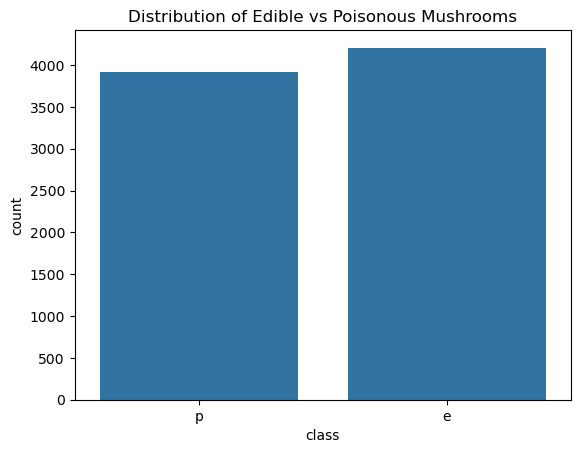

In [16]:
sns.countplot(x='class', data=df)

plt.title("Distribution of Edible vs Poisonous Mushrooms")
plt.show()

# 5. Data Cleaning
Check and handle missing values.

In [18]:
# Check missing values
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

# 6. Encoding Categorical Variables
The dataset contains categorical values.  
We convert them to numerical values using Label Encoding.

In [19]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


# 7. Feature Scaling
Feature scaling is applied using StandardScaler.

In [20]:
# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. Training the Decision Tree Model

In [22]:
# Create model
model = DecisionTreeClassifier()

# Train model
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [23]:
#model predictions
# Predict test data
y_pred = model.predict(X_test)

# 9. Model Evaluation

In [25]:
# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))
# Classification report
print(classification_report(y_test, y_pred))
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



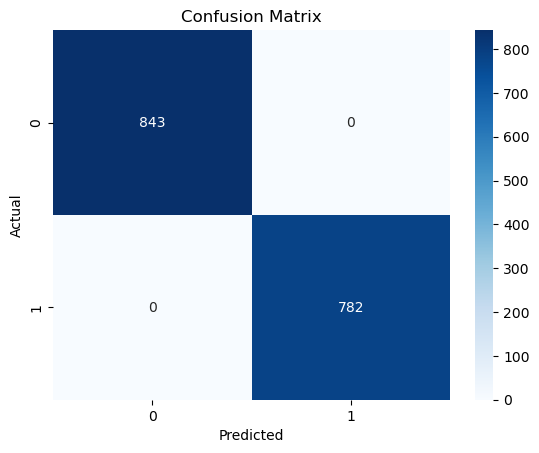

In [26]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 10. Decision Tree Visualization

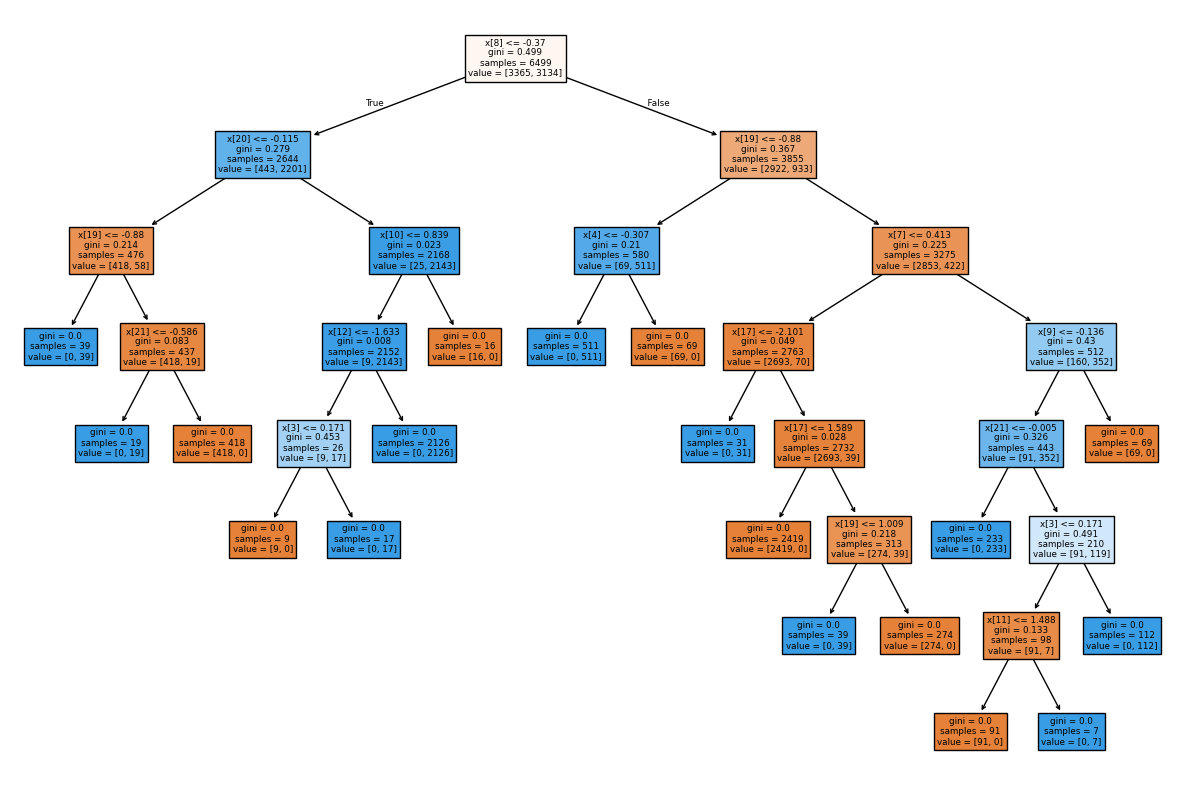

In [27]:
plt.figure(figsize=(15,10))

plot_tree(model, filled=True)

plt.show()

# 13. Hyperparameter Tuning (Pre-Pruning)

We tune parameters like:
- max_depth
- min_samples_split
- min_samples_leaf

In [29]:
depths = [3,5,7]
splits = [2,5,10]
leaves = [1,2,4]

best_acc = 0
best_params = None

for d in depths:
    for s in splits:
        for l in leaves:

            dt = DecisionTreeClassifier(
                max_depth=d,
                min_samples_split=s,
                min_samples_leaf=l
            )

            dt.fit(X_train, y_train)
            pred = dt.predict(X_test)

            acc = accuracy_score(y_test, pred)

            if acc > best_acc:
                best_acc = acc
                best_params = (d,s,l)

print("Accuracy:", best_acc)
print("Best Parameters:", best_params)

Accuracy: 1.0
Best Parameters: (7, 2, 1)
